# 3 - RandomForest

maintenant que tout est traité, on peut faire l'entrainement

In [59]:
import numpy as np
import pandas as pd
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, mean_absolute_error

In [60]:
# Usine N°1
DF_U1_Train = pd.read_csv("Data/csv/train_usine1.csv")
DF_U1_Test = pd.read_csv("Data/csv/test_usine1.csv")
DF_U1_Rul = pd.read_csv("Data/csv/rul_usine1.csv")

# Usine N°2
DF_U2_Train = pd.read_csv("Data/csv/train_usine2.csv")
DF_U2_Test = pd.read_csv("Data/csv/test_usine2.csv")
DF_U2_Rul = pd.read_csv("Data/csv/rul_usine2.csv")

## Usine 1 : 

In [61]:
# Features utiles : (determiné dans "Anlayse"
Features = ['cycle',
            'Température sortie LPC — T24',
            'Température sortie HPC — T30',
            'Température sortie LPT — T50',
            'Pression bypass — P15',
            'Pression sortie HPC — P30',
            'Vitesse fan — Nf',
            'Vitesse cœur — Nc',
            'Rapport pression moteur — EPR',
            'Pression statique HPC — Ps30',
            'Ratio carburant/pression — phi',
            'Vitesse corrigée fan — NRf',
            'Vitesse corrigée cœur — NRc',
            'Bypass Ratio — BPR',
            'Soutirage HPC — htBleed',
            'Débit refroid. HPT — W31',
            'Débit refroid. LPT — W32']

# répartitions
X_train_U1 = DF_U1_Train[Features]
y_train_U1 = DF_U1_Train["RUL"]

In [62]:
scaler = MinMaxScaler()
X_train_U1_scaled = scaler.fit_transform(X_train_U1)       # calcule min/max sur le train

# Sur le test : appliquer les MÊMES min/max, sans recalculer
X_test_U1_scaled = scaler.transform(DF_U1_Test[Features])

In [63]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_U1_scaled, y_train_U1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [64]:
DF_result  = scaler.transform(DF_U1_Test.groupby('machine_uid').last()[Features])
# Prédictions
y_Pred_U1 = rf.predict(DF_result)

In [65]:
y_true_U1 = DF_U1_Rul['RUL']

R2 = r2_score(y_true_U1, y_Pred_U1)
MAE = mean_absolute_error(y_true_U1, y_Pred_U1)
MSE = mean_squared_error(y_true_U1, y_Pred_U1)
RMSE = np.sqrt(MSE)

print(" ---------- Resultat ----------")
print(f"R² : {R2:.4f}")
print(f"MAE (erreur moyenne): {MAE:.2f}")
print(f"MSE (erreur au carré) : {MSE:.2f}")
print(f"RMSE (erreur écart-type) : {RMSE:.2f}")

 ---------- Resultat ----------
R² : -0.9027
MAE (erreur moyenne): 45.53
MSE (erreur au carré) : 3273.17
RMSE (erreur écart-type) : 57.21


In [66]:
# Ordre des machines dans les prédictions
print(DF_U1_Test.groupby('machine_uid').last().index[:5])

# Ordre des machines dans le RUL vrai
print(DF_U1_Rul['machine_uid'][:5])

Index(['100_1_1', '100_1_2', '10_1_1', '10_1_2', '11_1_1'], dtype='object', name='machine_uid')
0    1_1_1
1    2_1_1
2    3_1_1
3    4_1_1
4    5_1_1
Name: machine_uid, dtype: object


Les Rul est triée numériquement alors que mon test est alphabétique 

In [67]:
# L'ordre des machine_uid dans tes prédictions
ordre = DF_U1_Test.groupby('machine_uid').last().index

# Réordonner le RUL vrai dans ce même ordre
y_true = DF_U1_Rul.set_index('machine_uid').loc[ordre, 'RUL']
y_true_U1 = DF_U1_Rul['RUL']

R2 = r2_score(y_true, y_Pred_U1)
MAE = mean_absolute_error(y_true, y_Pred_U1)
MSE = mean_squared_error(y_true, y_Pred_U1)
RMSE = np.sqrt(MSE)

print(" ---------- Resultat ----------")
print(f"R² : {R2:.4f}")
print(f"MAE (erreur moyenne): {MAE:.2f}")
print(f"MSE (erreur au carré) : {MSE:.2f}")
print(f"RMSE (erreur écart-type) : {RMSE:.2f}")

 ---------- Resultat ----------
R² : 0.8048
MAE (erreur moyenne): 13.64
MSE (erreur au carré) : 335.83
RMSE (erreur écart-type) : 18.33


In [68]:
# Score PHM08 asymétrique
def phm_score_sur(rul_true, rul_pred):
    d = rul_pred - rul_true
    s = np.where(d < 0, np.exp(-d / 13) - 1, 0)
    return float(np.sum(s))

def phm_score_dang(rul_true, rul_pred):
    d = rul_pred - rul_true
    s = np.where(d > 0, np.exp(d / 10) - 1, 0)
    return float(np.sum(s))

PHMS = phm_score_sur(y_true, y_Pred_U1)
PHMD = phm_score_dang(y_true, y_Pred_U1)
print(f"PHM08 Sur : {PHMS/100}")
print(f"PHM08 Dangereux : {PHMD/100}")

PHM08 Sur : 4.180011832313695
PHM08 Dangereux : 9.148694788096872


Le PHM08 sert a savoir si le modèle prédit en majorité + de cycle de vie ou moins.
PHMS est "Sur" car c'est lorsque le modèle prédit -
PHMD est "dangereux" car c'est lorsque le modèle prédit +, c'est a dire il surestime la durée de vie de la machine ce que l'on veut pas

Et en regardant les résultat le modèle prédit + de cycle que - de cycle

In [69]:
# Score PHM08 asymétrique
DF_PHMS =[]
def construire_table_erreurs(y_true, y_pred, machine_uid):
    d = y_pred - y_true
    df = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
        'd': d
    })
    return df

DF_PHMS = construire_table_erreurs(y_true, y_Pred_U1, y_true.index)
DF_PHMS

,y_true,y_pred,d
machine_uid,,,
100_1_1,20,16.45,-3.55
100_1_2,28,32.99,4.99
10_1_1,96,100.88,4.88
10_1_2,66,96.29,30.29
11_1_1,97,79.22,-17.78
...,...,...,...
98_1_2,17,20.46,3.46
99_1_1,117,120.32,3.32
99_1_2,8,11.08,3.08


In [70]:
DF_PHMS.sort_values('d', ascending=False).head(10)

,y_true,y_pred,d
machine_uid,,,
93_1_2,67,115.78,48.78
41_1_1,18,64.45,46.45
58_1_2,40,84.42,44.42
70_1_2,63,107.16,44.16
2_1_2,51,91.67,40.67
54_1_2,87,122.24,35.24
15_1_1,83,118.15,35.15
89_1_2,41,75.03,34.03
91_1_2,81,112.02,31.02


In [71]:
DF_PHMS.sort_values('d', ascending=True).head(10)

,y_true,y_pred,d
machine_uid,,,
83_1_2,145,90.98,-54.02
45_1_1,114,70.63,-43.37
30_1_1,115,73.71,-41.29
17_1_2,136,95.12,-40.88
74_1_1,126,86.34,-39.66
89_1_1,136,96.75,-39.25
51_1_1,114,75.32,-38.68
12_1_2,115,78.54,-36.46
93_1_1,85,48.84,-36.16


In [72]:
masque_risque = y_train_U1 <= 30
n_risque = masque_risque.sum()
n_total = len(y_train_U1)
proportion = n_risque / n_total
n_normaux = n_total - n_risque
print(f"Nombre de lignes a risque : {n_risque}") # donne le nombre de lignes du train où le RUL vrai est ≤ 30 
print(f"Nombre de lignes normaux : {n_normaux}") # le nombre de lignes du train "normaux"
print(f"Nombre de lignes totaux : {n_total}") # donne le nombre total de lignes du train
print(f"Pourcentage de critique dans le document : {proportion * 100}%") # dit quelle part ça représente dans tout le jeu d'entraînement.

ratio = (1 - proportion) / proportion
weights = np.where(masque_risque, 12, 1)
print(f"Facteur multiplicateur pour les 'A risque' : {ratio}")

Nombre de lignes a risque : 6200
Nombre de lignes normaux : 39151
Nombre de lignes totaux : 45351
Pourcentage de critique dans le document : 13.671142863442922%
Facteur multiplicateur pour les 'A risque' : 6.314677419354839


Ici, on voit que les zones a risques représente 13,67 % du dataset. Il faut donc ajouter un facteur de 6.3 a toute ces données afin de rééquilibrer

In [73]:
rf2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf2.fit(X_train_U1_scaled, y_train_U1, sample_weight=weights)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [74]:
y_Pred_U1b = rf2.predict(DF_result)
R2 = r2_score(y_true, y_Pred_U1b)
MAE = mean_absolute_error(y_true, y_Pred_U1b)
MSE = mean_squared_error(y_true, y_Pred_U1b)
RMSE = np.sqrt(MSE)
print(" ---------- Resultat ----------")
print(f"R² : {R2:.4f}")
print(f"MAE (erreur moyenne): {MAE:.2f}")
print(f"MSE (erreur au carré) : {MSE:.2f}")
print(f"RMSE (erreur écart-type) : {RMSE:.2f}")

 ---------- Resultat ----------
R² : 0.8101
MAE (erreur moyenne): 13.65
MSE (erreur au carré) : 326.70
RMSE (erreur écart-type) : 18.07


In [75]:
PHMS = phm_score_sur(y_true, y_Pred_U1b)
PHMD = phm_score_dang(y_true, y_Pred_U1b)
print(f"PHM08 Sur : {PHMS/100}")
print(f"PHM08 Dangereux : {PHMD/100}")

PHM08 Sur : 4.251233890675261
PHM08 Dangereux : 7.604191848488983


## Usine 2

In [77]:
# Features utiles : (determiné dans "Anlayse"
FeaturesU2 = ['cycle',
            'Pression statique HPC — Ps30',
            'Température sortie HPC — T30',
            'Température sortie LPT — T50',
            'Pression bypass — P15',
            'Pression sortie HPC — P30',
            'Vitesse fan — Nf',
            'Vitesse cœur — Nc',
            'Rapport pression moteur — EPR',
            'Ratio carburant/pression — phi',
            'Vitesse corrigée fan — NRf',
            'Vitesse corrigée cœur — NRc',
            'Bypass Ratio — BPR',
            'Soutirage HPC — htBleed',
            'Débit refroid. HPT — W31',
            'Débit refroid. LPT — W32',
            'Température sortie LPC — T24',
            'Richesse carburant — farB'
           ]
# répartitions
X_train_U2 = DF_U2_Train[FeaturesU2]
y_train_U2 = DF_U2_Train["RUL"]
X_train_U2_scaled = scaler.fit_transform(X_train_U2)       # calcule min/max sur le train

# Sur le test : appliquer les MÊMES min/max, sans recalculer
X_test_U2_scaled = scaler.transform(DF_U2_Test[FeaturesU2])
rfU2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rfU2.fit(X_train_U2_scaled, y_train_U2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [78]:
DF_result_U2  = scaler.transform(DF_U2_Test.groupby('machine_uid').last()[FeaturesU2])
# Prédictions
y_Pred_U2 = rfU2.predict(DF_result_U2)

# L'ordre des machine_uid dans tes prédictions
ordre_U2 = DF_U2_Test.groupby('machine_uid').last().index

# Réordonner le RUL vrai dans ce même ordre
y_true_U2 = DF_U2_Rul.set_index('machine_uid').loc[ordre_U2, 'RUL']

R2 = r2_score(y_true_U2, y_Pred_U2)
MAE = mean_absolute_error(y_true_U2, y_Pred_U2)
MSE = mean_squared_error(y_true_U2, y_Pred_U2)
RMSE = np.sqrt(MSE)

print(" ---------- Resultat ----------")
print(f"R² : {R2:.4f}")
print(f"MAE (erreur moyenne): {MAE:.2f}")
print(f"MSE (erreur au carré) : {MSE:.2f}")
print(f"RMSE (erreur écart-type) : {RMSE:.2f}")

 ---------- Resultat ----------
R² : 0.7258
MAE (erreur moyenne): 20.52
MSE (erreur au carré) : 805.73
RMSE (erreur écart-type) : 28.39


In [79]:
masque_risque = y_train_U2 <= 30
n_risque = masque_risque.sum()
n_total = len(y_train_U2)
proportion = n_risque / n_total
n_normaux = n_total - n_risque
print(f"Nombre de lignes a risque : {n_risque}") # donne le nombre de lignes du train où le RUL vrai est ≤ 30 
print(f"Nombre de lignes normaux : {n_normaux}") # le nombre de lignes du train "normaux"
print(f"Nombre de lignes totaux : {n_total}") # donne le nombre total de lignes du train
print(f"Pourcentage de critique dans le document : {proportion * 100}%") # dit quelle part ça représente dans tout le jeu d'entraînement.

ratio = (1 - proportion) / proportion
weights = np.where(masque_risque, 12, 1)
print(f"Facteur multiplicateur pour les 'A risque' : {ratio}")

rfU2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rfU2.fit(X_train_U2_scaled, y_train_U2, sample_weight=weights)

y_Pred_U2B = rfU2.predict(DF_result_U2)
R2 = r2_score(y_true_U2, y_Pred_U2B)
MAE = mean_absolute_error(y_true_U2, y_Pred_U2B)
MSE = mean_squared_error(y_true_U2, y_Pred_U2B)
RMSE = np.sqrt(MSE)
print(" ---------- Resultat ----------")
print(f"R² : {R2:.4f}")
print(f"MAE (erreur moyenne): {MAE:.2f}")
print(f"MSE (erreur au carré) : {MSE:.2f}")
print(f"RMSE (erreur écart-type) : {RMSE:.2f}")

PHMS = phm_score_sur(y_true_U2, y_Pred_U2B)
PHMD = phm_score_dang(y_true_U2, y_Pred_U2B)
print(f"PHM08 Sur : {PHMS/100}")
print(f"PHM08 Dangereux : {PHMD/100}")

Nombre de lignes a risque : 15779
Nombre de lignes normaux : 99229
Nombre de lignes totaux : 115008
Pourcentage de critique dans le document : 13.719915136338342%
Facteur multiplicateur pour les 'A risque' : 6.288674820964572
 ---------- Resultat ----------
R² : 0.7254
MAE (erreur moyenne): 20.47
MSE (erreur au carré) : 807.12
RMSE (erreur écart-type) : 28.41
PHM08 Sur : 145.32785092439286
PHM08 Dangereux : 20.86620493325745


In [80]:
# Score PHM08 asymétrique
DF_PHMS_U2 =[]

DF_PHMS_U2 = construire_table_erreurs(y_true_U2, y_Pred_U2B, y_true_U2.index)
DF_PHMS_U2

,y_true,y_pred,d
machine_uid,,,
100_2_1,14,18.01,4.01
100_2_2,7,10.99,3.99
101_2_1,106,120.89,14.89
101_2_2,13,15.54,2.54
102_2_1,8,6.65,-1.35
...,...,...,...
98_2_2,113,117.14,4.14
99_2_1,9,15.54,6.54
99_2_2,37,53.63,16.63


In [81]:
print(DF_PHMS_U2.sort_values('d', ascending=False).head(10))
print(DF_PHMS_U2.sort_values('d', ascending=True).head(10))

             y_true  y_pred      d
machine_uid                       
43_2_2           42   95.97  53.97
121_2_1          67  114.52  47.52
209_2_1          23   69.27  46.27
189_2_2          56  101.52  45.52
166_2_2          72  117.40  45.40
56_2_2           67  111.40  44.40
152_2_1          59  102.67  43.67
198_2_1          32   75.30  43.30
12_2_1           73  114.32  41.32
259_2_1          51   88.71  37.71
             y_true  y_pred      d
machine_uid                       
166_2_1         188   91.09 -96.91
235_2_1         190   93.65 -96.35
86_2_1          194   99.79 -94.21
188_2_1         183  100.24 -82.76
95_2_2          171   91.34 -79.66
127_2_2         195  115.94 -79.06
93_2_1          183  104.32 -78.68
170_2_1         182  105.00 -77.00
256_2_1         191  114.40 -76.60
39_2_2          151   74.47 -76.53


Les résultats montrent que les R² sont de 71 soit plus faible à l'usine 1. donc un changement de features et surement necessaire car avec 6 conditions les features necessaire ne sont pas les mêmes.

Cependant avec l'analyse suivante, le R² est passé de 71 à 72. Les features y sont aps exactement pour quelque choses.

In [82]:
# Les 3 réglages opérationnels qui définissent le régime de vol
Reglages = ['Altitude / Mach', 'Throttle Resolver Angle (TRA)', 'Altitude pressurisée']

def ajouter_regime(df):
    df = df.copy()
    # On arrondit pour gommer le bruit de mesure : chaque combinaison arrondie = 1 régime
    arrondi = df[Reglages].round({'Altitude / Mach': 0,
                                  'Throttle Resolver Angle (TRA)': 2,
                                  'Altitude pressurisée': 0})
    df['regime'] = arrondi.apply(tuple, axis=1)
    return df

DF_U2_Train = ajouter_regime(DF_U2_Train)
DF_U2_Test = ajouter_regime(DF_U2_Test)

# Vérification : on doit voir exactement 6 groupes, bien remplis
print(DF_U2_Train['regime'].value_counts())

regime
(42.0, 0.84, 100.0)    28853
(10.0, 0.25, 100.0)    17320
(0.0, 0.0, 100.0)      17282
(20.0, 0.7, 100.0)     17213
(35.0, 0.84, 100.0)    17199
(25.0, 0.62, 60.0)     17141
Name: count, dtype: int64


In [83]:
# Tous les capteurs = toutes les colonnes sauf identifiants, réglages et RUL
Colonnes_exclues = ['machine_id', 'cycle', 'usine', 'ligne_production',
                    'machine_uid', 'RUL', 'regime'] + Reglages
Capteurs = [c for c in DF_U2_Train.columns if c not in Colonnes_exclues]

# Moyenne et écart-type de chaque capteur DANS chaque régime (sur le train uniquement)
moyennes_regime = DF_U2_Train.groupby('regime')[Capteurs].mean()
ecarts_regime = DF_U2_Train.groupby('regime')[Capteurs].std().replace(0, 1)  # évite /0 sur capteurs constants

def normaliser_par_regime(df):
    df_norm = df.copy()
    df_norm[Capteurs] = (df[Capteurs].values
                         - moyennes_regime.loc[df['regime']].values) \
                         / ecarts_regime.loc[df['regime']].values
    return df_norm

DF_U2_Train_norm = normaliser_par_regime(DF_U2_Train)
DF_U2_Test_norm = normaliser_par_regime(DF_U2_Test)

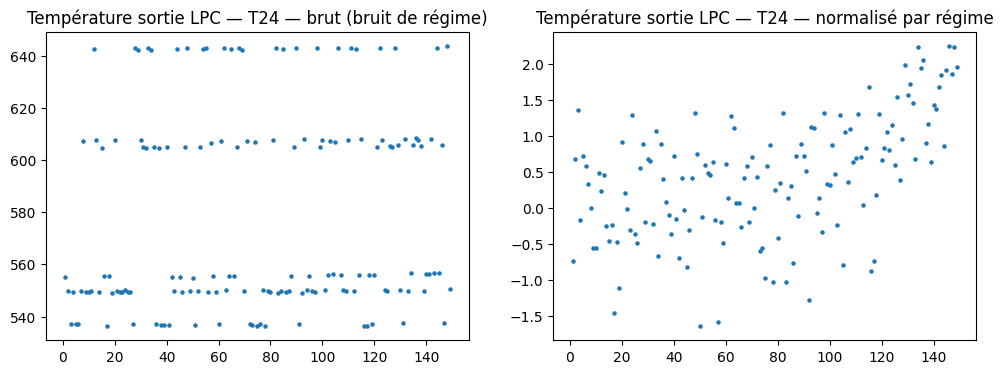

In [84]:
import matplotlib.pyplot as plt

machine = DF_U2_Train['machine_uid'].iloc[0]
capteur = 'Température sortie LPC — T24'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
brut = DF_U2_Train[DF_U2_Train['machine_uid'] == machine]
norm = DF_U2_Train_norm[DF_U2_Train_norm['machine_uid'] == machine]

axes[0].scatter(brut['cycle'], brut[capteur], s=5)
axes[0].set_title(f"{capteur} — brut (bruit de régime)")
axes[1].scatter(norm['cycle'], norm[capteur], s=5)
axes[1].set_title(f"{capteur} — normalisé par régime")
plt.show()

In [85]:
# Corrélation de chaque capteur normalisé avec le RUL : plus c'est loin de 0, plus c'est utile
correlations = DF_U2_Train_norm[Capteurs].corrwith(DF_U2_Train_norm['RUL'])
correlations = correlations.sort_values(key=abs, ascending=False)

print(" ---------- Corrélation capteurs / RUL (Usine 2, normalisé par régime) ----------")
print(correlations)

 ---------- Corrélation capteurs / RUL (Usine 2, normalisé par régime) ----------
Pression statique HPC — Ps30        -0.758572
Température sortie LPT — T50        -0.723811
Soutirage HPC — htBleed             -0.660006
Température sortie HPC — T30        -0.634788
Température sortie LPC — T24        -0.601776
Vitesse cœur — Nc                   -0.527254
Vitesse corrigée fan — NRf          -0.502863
Vitesse fan — Nf                    -0.502154
Vitesse corrigée cœur — NRc         -0.435672
Bypass Ratio — BPR                  -0.234487
Débit refroid. HPT — W31             0.223108
Débit refroid. LPT — W32             0.220590
Rapport pression moteur — EPR       -0.211851
Richesse carburant — farB           -0.188413
Pression bypass — P15               -0.167489
Ratio carburant/pression — phi      -0.135686
Pression sortie HPC — P30           -0.109543
Température entrée fan — T2          0.000454
Pression entrée fan — P2                  NaN
Consigne vitesse fan — Nf_dmd             Na

D:\Cours\VenvPyt\MECHA_IA_MSPR\Samuel\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
D:\Cours\VenvPyt\MECHA_IA_MSPR\Samuel\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
